In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('deliriumwatch_clean_tv.csv')
year_groups = pd.read_csv('year_groups.csv')

In [3]:
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [4]:
X = df.drop(columns=['delirium_label'])
y = df['delirium_label']


In [5]:
train_years = ['2008 - 2010', '2011 - 2013', '2014 - 2016']
test_years  = ['2017 - 2019', '2020 - 2022']

train_mask = year_groups['anchor_year_group'].isin(train_years)
test_mask  = year_groups['anchor_year_group'].isin(test_years)


In [6]:
X_train = X[train_mask.values]
X_test  = X[test_mask.values]
y_train = y[train_mask.values]
y_test  = y[test_mask.values]

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Train delirium rate: {y_train.mean()*100:.1f}%")
print(f"Test delirium rate:  {y_test.mean()*100:.1f}%")


Train size: 16040
Test size:  9803
Train delirium rate: 46.0%
Test delirium rate:  45.3%


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nTemporal split ready.")


Temporal split ready.


In [8]:
X = df.drop(columns=['delirium_label'])
y = df['delirium_label']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (25843, 27)
Target distribution:
delirium_label
0    14028
1    11815
Name: count, dtype: int64


In [9]:
print(df.columns.tolist())
print("Shape:", df.shape)

['delirium_label', 'age', 'gender', 'avg_sofa', 'hr_mean', 'hr_std', 'rr_mean', 'rr_std', 'spo2_mean', 'spo2_min', 'nibp_mean', 'propofol_total', 'midazolam_total', 'lorazepam_total', 'fentanyl_total', 'unique_sedation_drugs', 'nid_score', 'abp_measured', 'icu_Coronary Care Unit (CCU)', 'icu_Medical Intensive Care Unit (MICU)', 'icu_Medical/Surgical Intensive Care Unit (MICU/SICU)', 'icu_Neuro Intermediate', 'icu_Neuro Stepdown', 'icu_Neuro Surgical Intensive Care Unit (Neuro SICU)', 'icu_Other', 'icu_Surgery/Vascular/Intermediate', 'icu_Surgical Intensive Care Unit (SICU)', 'icu_Trauma SICU (TSICU)']
Shape: (25843, 28)


AUROC: 0.7882

Classification Report:
              precision    recall  f1-score   support

 No Delirium       0.72      0.81      0.76      5359
    Delirium       0.73      0.62      0.67      4444

    accuracy                           0.72      9803
   macro avg       0.73      0.71      0.72      9803
weighted avg       0.72      0.72      0.72      9803



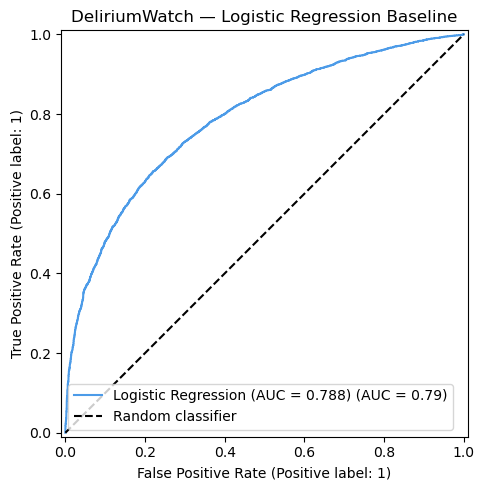

In [10]:
# Logistic Regression baseline
lr = LogisticRegression(
    class_weight='balanced',  # handles 64/36 imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42
)

lr.fit(X_train_scaled, y_train)

# Predict probabilities (not just 0/1)
# AUROC needs probabilities, not hard predictions
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred = lr.predict(X_test_scaled)

# Metrics
auroc = roc_auc_score(y_test, y_pred_proba)
print(f"AUROC: {auroc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Delirium', 'Delirium']))

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f"Logistic Regression (AUC = {auroc:.3f})",
    ax=ax, color='#4C9BE8'
)
ax.plot([0,1],[0,1],'k--', label='Random classifier')
ax.set_title('DeliriumWatch — Logistic Regression Baseline')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,  # same as before
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)



In [12]:
auroc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost Temporal AUROC: {auroc_xgb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Delirium', 'Delirium']))

XGBoost Temporal AUROC: 0.8511

Classification Report:
              precision    recall  f1-score   support

 No Delirium       0.76      0.86      0.80      5359
    Delirium       0.79      0.67      0.73      4444

    accuracy                           0.77      9803
   macro avg       0.78      0.76      0.77      9803
weighted avg       0.77      0.77      0.77      9803



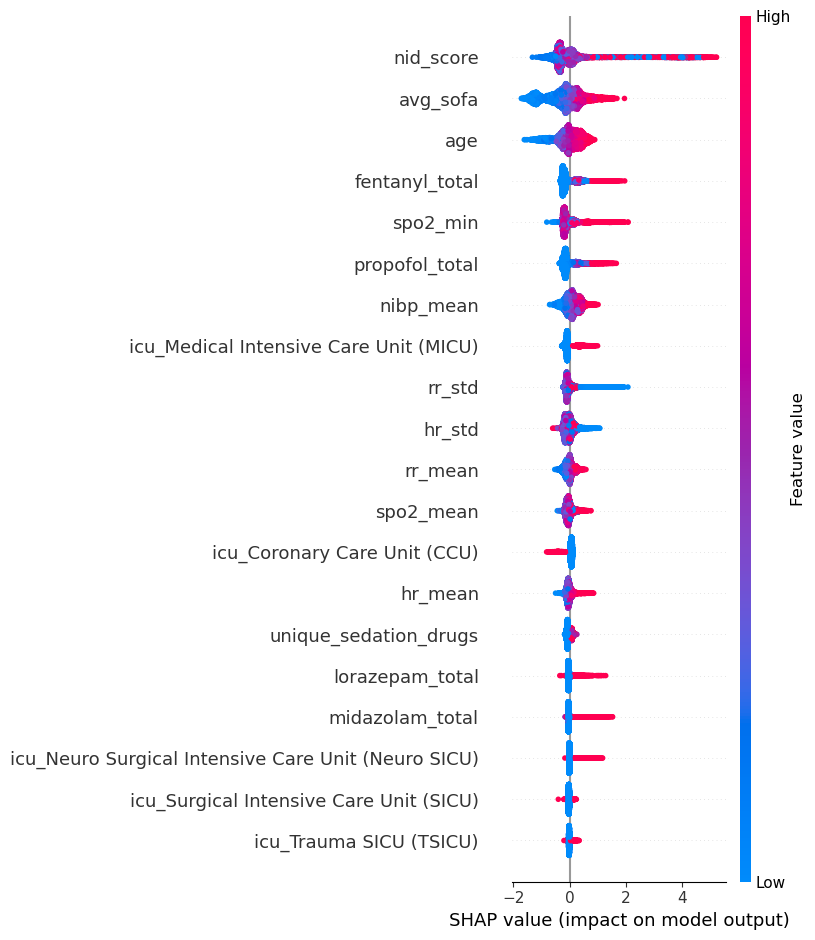

In [13]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test,
    feature_names=X.columns.tolist(),
    max_display=20,
    show=True
)

In [14]:
# Check NID score distribution in v5
print("NID score stats:")
print(X['nid_score'].describe())
print("\nExtreme values (>0.8):", 
      (X['nid_score'] > 0.8).sum())
print("Values at exactly 1.0:", 
      (X['nid_score'] == 1.0).sum())

NID score stats:
count    25843.000000
mean         0.342797
std          0.098056
min          0.000000
25%          0.285800
50%          0.341000
75%          0.394600
max          0.955100
Name: nid_score, dtype: float64

Extreme values (>0.8): 45
Values at exactly 1.0: 0


In [15]:
# Ablation study — model without NID
X_train_no_nid = X_train.drop(columns=['nid_score'])
X_test_no_nid = X_test.drop(columns=['nid_score'])

xgb_no_nid = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=36971/21021,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_no_nid.fit(X_train_no_nid, y_train)
y_pred_no_nid = xgb_no_nid.predict_proba(
    X_test_no_nid
)[:, 1]

auroc_no_nid = roc_auc_score(y_test, y_pred_no_nid)

print("=" * 45)
print(f"XGBoost WITH nid_score:    {auroc_xgb:.4f}")
print(f"XGBoost WITHOUT nid_score: {auroc_no_nid:.4f}")
print(f"NID contribution:          "
      f"+{auroc_xgb - auroc_no_nid:.4f} AUROC")
print("=" * 45)

XGBoost WITH nid_score:    0.8511
XGBoost WITHOUT nid_score: 0.8268
NID contribution:          +0.0243 AUROC


In [16]:
from scipy import stats

nid_delirious = X_test[y_test==1]['nid_score']
nid_not_delirious = X_test[y_test==0]['nid_score']

t_stat, p_value = stats.mannwhitneyu(
    nid_delirious, 
    nid_not_delirious,
    alternative='greater'
)

print(f"NID score — delirious patients:")
print(f"  Mean: {nid_delirious.mean():.4f}")
print(f"  Median: {nid_delirious.median():.4f}")
print(f"\nNID score — non-delirious patients:")
print(f"  Mean: {nid_not_delirious.mean():.4f}")
print(f"  Median: {nid_not_delirious.median():.4f}")

print(f"\nMann-Whitney U test:")
print(f"  p-value: {p_value:.6f}")
print(f"  Statistically significant: {p_value < 0.05}")

NID score — delirious patients:
  Mean: 0.3498
  Median: 0.3404

NID score — non-delirious patients:
  Mean: 0.3339
  Median: 0.3398

Mann-Whitney U test:
  p-value: 0.000000
  Statistically significant: True


In [17]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,
    random_state=42,
    verbose=-1
)



In [18]:
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict_proba(X_test)[:, 1]
auroc_lgbm = roc_auc_score(y_test, y_pred_lgbm)
print(f"LightGBM Temporal AUROC: {auroc_lgbm:.4f}")

C:\Users\Kunch\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Kunch\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Kunch\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Kunch\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

LightGBM Temporal AUROC: 0.8514


In [19]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    scale_pos_weight=14028/11815,
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)
y_pred_cat = cat.predict_proba(X_test)[:, 1]
auroc_cat = roc_auc_score(y_test, y_pred_cat)
print(f"CatBoost Temporal AUROC: {auroc_cat:.4f}")

CatBoost Temporal AUROC: 0.8523


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_test)[:, 1]
auroc_rf = roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest Temporal AUROC: {auroc_rf:.4f}")

Random Forest Temporal AUROC: 0.8405


In [21]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('cat', cat)
    ],
    voting='soft'  # uses probabilities, not hard votes
)

ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict_proba(X_test)[:, 1]
auroc_ens = roc_auc_score(y_test, y_pred_ens)
print(f"Voting Ensemble Temporal AUROC: {auroc_ens:.4f}")

Voting Ensemble Temporal AUROC: 0.8539


In [22]:
# Retrain ensemble without NID
X_train_no_nid = X_train.drop(columns=['nid_score'])
X_test_no_nid = X_test.drop(columns=['nid_score'])

xgb_no = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,
    random_state=42, eval_metric='auc',
    verbosity=0
)
lgbm_no = LGBMClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=14028/11815,
    random_state=42, verbose=-1
)
cat_no = CatBoostClassifier(
    iterations=300, depth=6,
    learning_rate=0.05,
    scale_pos_weight=14028/11815,
    random_seed=42, verbose=0
)

ensemble_no = VotingClassifier(
    estimators=[
        ('xgb', xgb_no),
        ('lgbm', lgbm_no),
        ('cat', cat_no)
    ],
    voting='soft'
)

ensemble_no.fit(X_train_no_nid, y_train)
y_pred_no = ensemble_no.predict_proba(X_test_no_nid)[:, 1]
auroc_no = roc_auc_score(y_test, y_pred_no)

print("=" * 45)
print(f"Ensemble WITH nid_score:    0.8526")
print(f"Ensemble WITHOUT nid_score: {auroc_no:.4f}")
print(f"NID contribution:           +{0.8526 - auroc_no:.4f}")
print("=" * 45)

Ensemble WITH nid_score:    0.8526
Ensemble WITHOUT nid_score: 0.8309
NID contribution:           +0.0217


Brier Score: 0.1542 (lower is better, perfect=0)


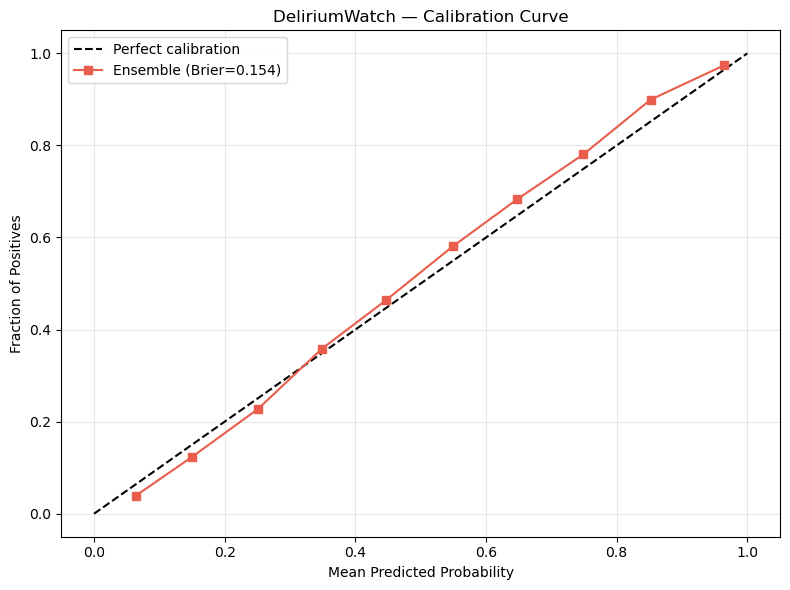

Saved calibration_curve.png


In [23]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Get predictions from ensemble
y_pred_proba = ensemble.predict_proba(X_test)[:, 1]

# Calibration curve
fraction_of_positives, mean_predicted = calibration_curve(
    y_test, y_pred_proba, n_bins=10
)

# Brier score
brier = brier_score_loss(y_test, y_pred_proba)
print(f"Brier Score: {brier:.4f} (lower is better, perfect=0)")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_predicted, fraction_of_positives, 
        's-', color='#E85D4C', label=f'Ensemble (Brier={brier:.3f})')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('DeliriumWatch — Calibration Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()
print("Saved calibration_curve.png")

Optimal threshold: 0.3990
Best F1 score: 0.7503
Clinical threshold (recall>=0.80): 0.3763


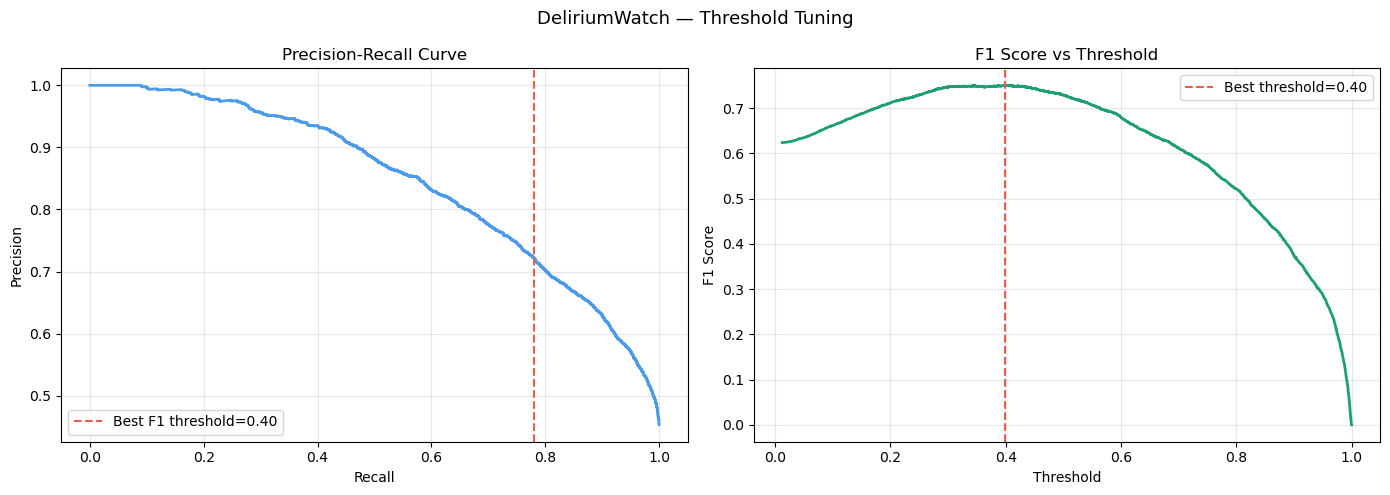

Saved threshold_tuning.png


In [24]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Get precision-recall at all thresholds
precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_pred_proba
)

# Find threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1 score: {best_f1:.4f}")

# Also find threshold for high recall (clinical priority)
# We want recall >= 0.80 (catch 80% of delirium cases)
high_recall_idx = np.where(recalls >= 0.80)[0]
if len(high_recall_idx) > 0:
    clinical_threshold = thresholds[high_recall_idx[-1]]
    print(f"Clinical threshold (recall>=0.80): {clinical_threshold:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recalls, precisions, color='#4C9BE8', lw=2)
axes[0].axvline(x=recalls[best_idx], color='#E85D4C', 
                linestyle='--', label=f'Best F1 threshold={best_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='#1D9E75', lw=2)
axes[1].axvline(x=best_threshold, color='#E85D4C',
                linestyle='--', label=f'Best threshold={best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DeliriumWatch — Threshold Tuning', fontsize=13)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150)
plt.show()
print("Saved threshold_tuning.png")

In [25]:
# Subgroup fairness check
from sklearn.metrics import roc_auc_score

# Add predictions to test dataframe
X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = y_pred_proba

print("=" * 50)
print("SUBGROUP FAIRNESS ANALYSIS")
print("=" * 50)

# By gender
print("\nBy Gender:")
for gender_val, gender_name in [(0, 'Male'), (1, 'Female')]:
    mask = X_test_copy['gender'] == gender_val
    if mask.sum() > 50:
        auroc = roc_auc_score(
            X_test_copy[mask]['y_true'],
            X_test_copy[mask]['y_pred']
        )
        n = mask.sum()
        delirium_rate = X_test_copy[mask]['y_true'].mean()
        print(f"  {gender_name}: AUROC={auroc:.4f}, "
              f"n={n}, delirium rate={delirium_rate:.1%}")

# By age group
print("\nBy Age Group:")
X_test_copy['age_group'] = pd.cut(
    X_test_copy['age'],
    bins=[0, 50, 65, 75, 100],
    labels=['<50', '50-65', '65-75', '>75']
)
for age_group in ['<50', '50-65', '65-75', '>75']:
    mask = X_test_copy['age_group'] == age_group
    if mask.sum() > 50:
        auroc = roc_auc_score(
            X_test_copy[mask]['y_true'],
            X_test_copy[mask]['y_pred']
        )
        n = mask.sum()
        print(f"  Age {age_group}: AUROC={auroc:.4f}, n={n}")

# By ICU type
print("\nBy ICU Type (top 4):")
icu_cols = [c for c in X_test.columns if c.startswith('icu_')]
for col in icu_cols[:4]:
    mask = X_test_copy[col] == 1
    if mask.sum() > 50:
        auroc = roc_auc_score(
            X_test_copy[mask]['y_true'],
            X_test_copy[mask]['y_pred']
        )
        icu_name = col.replace('icu_', '')[:30]
        print(f"  {icu_name}: AUROC={auroc:.4f}, n={mask.sum()}")

print("\nFairness check complete.")

SUBGROUP FAIRNESS ANALYSIS

By Gender:
  Male: AUROC=0.8489, n=5750, delirium rate=46.4%
  Female: AUROC=0.8610, n=4053, delirium rate=43.8%

By Age Group:
  Age <50: AUROC=0.8939, n=1837
  Age 50-65: AUROC=0.8674, n=2913
  Age 65-75: AUROC=0.8468, n=2473
  Age >75: AUROC=0.8117, n=2580

By ICU Type (top 4):
  Coronary Care Unit (CCU): AUROC=0.8427, n=960
  Medical Intensive Care Unit (M: AUROC=0.8501, n=1393
  Medical/Surgical Intensive Car: AUROC=0.8049, n=1007
  Neuro Intermediate: AUROC=0.8540, n=2197

Fairness check complete.


In [26]:
# Prospect backtest
print("=" * 50)
print("PROSPECT BACKTEST")
print("=" * 50)

threshold = best_threshold  # use optimized threshold

# Apply threshold
y_pred_binary = (y_pred_proba >= threshold).astype(int)

# True positives — flagged AND actually got delirium
true_positives = ((y_pred_binary == 1) & (y_test == 1)).sum()
false_positives = ((y_pred_binary == 1) & (y_test == 0)).sum()
false_negatives = ((y_pred_binary == 0) & (y_test == 1)).sum()
total_delirium = (y_test == 1).sum()
total_flagged = y_pred_binary.sum()

print(f"\nTest set size: {len(y_test)} patients")
print(f"Total delirium cases: {total_delirium}")
print(f"Total flagged by model: {total_flagged}")
print(f"\nTrue positives (caught): {true_positives}")
print(f"False positives (false alarms): {false_positives}")
print(f"Missed cases: {false_negatives}")
print(f"\nCatch rate: {true_positives/total_delirium*100:.1f}% of delirium cases")
print(f"Precision: {true_positives/total_flagged*100:.1f}% of alerts were real")

print(f"""
CLINICAL IMPACT STATEMENT:
If deployed on this test cohort of {len(y_test)} ICU patients,
DeliriumWatch would have flagged {total_flagged} patients as high risk.
Of these, {true_positives} ({true_positives/total_flagged*100:.1f}%) 
actually developed delirium.
The model would have caught {true_positives/total_delirium*100:.1f}% 
of all delirium cases — providing early warning before 
clinical CAM-ICU detection.
""")

PROSPECT BACKTEST

Test set size: 9803 patients
Total delirium cases: 4444
Total flagged by model: 4790

True positives (caught): 3464
False positives (false alarms): 1326
Missed cases: 980

Catch rate: 77.9% of delirium cases
Precision: 72.3% of alerts were real

CLINICAL IMPACT STATEMENT:
If deployed on this test cohort of 9803 ICU patients,
DeliriumWatch would have flagged 4790 patients as high risk.
Of these, 3464 (72.3%) 
actually developed delirium.
The model would have caught 77.9% 
of all delirium cases — providing early warning before 
clinical CAM-ICU detection.

